Looping

In [1]:
from langgraph.graph import StateGraph, END
import random
from typing import TypedDict, List

In [2]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [ ]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node which says hi to the person"""

    state["name"] = f"Hi there, {state["name"]}"
    state["counter"] = 0 

    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""

    state["number"].append(random.randint(0, 10))
    state["counter"] += 1

    return state


def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""

    if state["counter"] < 5:
        print("Entering Loop", state["counter"])
        return "loop"
    else:
        return "exit"

In [4]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)
graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit": END,
    }, 
)

graph.set_entry_point("greeting")

app = graph.compile()

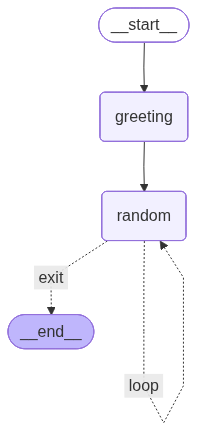

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
app.invoke({"name":"Kübra", "number":[]})

Entering Loop 1
Entering Loop 2
Entering Loop 3
Entering Loop 4


{'name': 'Hi there, Kübra', 'number': [6, 9, 5, 8, 1], 'counter': 5}